In [1]:
# Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import zipfile

from scipy.optimize import curve_fit
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from io import StringIO


plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)

In [2]:
# Load data

zip_path = r"C:\Users\akind\Downloads\Global Population (1).zip"
df = pd.read_csv(zipfile.ZipFile(zip_path).open('Global_annual_population.csv'))
df = df.rename(columns=lambda x: x.strip().replace(',', ''))
df['Year'] = df['Year'].astype(int)
df['Population'] = df['Population'].astype(float)
df['Years_Since_1960'] = df['Year'] - 1960

In [3]:
# Display the shape of the dataset
print("Dataset Shape:", df.shape)
print("\nFirst 20 rows of the dataset:")
display(df.head(20))
print("\nLast 10 rows:")
print(df.tail(10))

Dataset Shape: (63, 4)

First 20 rows of the dataset:


,Year,Population,Unnamed: 2,Years_Since_1960
0,1960,3.03,NaN,0
1,1961,3.07,NaN,1
2,1962,3.12,NaN,2
3,1963,3.19,NaN,3
4,1964,3.26,NaN,4
5,1965,3.32,NaN,5
6,1966,3.39,NaN,6
7,1967,3.46,NaN,7
8,1968,3.53,NaN,8
9,1969,3.61,NaN,9



Last 10 rows:
    Year  Population  Unnamed: 2  Years_Since_1960
53  2013        7.18         NaN                53
54  2014        7.26         NaN                54
55  2015        7.35         NaN                55
56  2016        7.43         NaN                56
57  2017        7.52         NaN                57
58  2018        7.60         NaN                58
59  2019        7.68         NaN                59
60  2020        7.76         NaN                60
61  2021        7.84         NaN                61
62  2022        7.95         NaN                62


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              63 non-null     int64  
 1   Population        63 non-null     float64
 2   Unnamed: 2        0 non-null      float64
 3   Years_Since_1960  63 non-null     int64  
dtypes: float64(2), int64(2)
memory usage: 2.1 KB


In [5]:
df.describe()

,Year,Population,Unnamed: 2,Years_Since_1960
count,63.000000,63.000000,0.0,63.000000
mean,1991.000000,5.383175,NaN,31.000000
std,18.330303,1.482324,NaN,18.330303
min,1960.000000,3.030000,NaN,0.000000
25%,1975.500000,4.100000,NaN,15.500000
50%,1991.000000,5.370000,NaN,31.000000
75%,2006.500000,6.630000,NaN,46.500000
max,2022.000000,7.950000,NaN,62.000000


In [6]:
# DATA CLEANING & BASIC CHECKS
print("DATA CLEANING & BASIC CHECKS")
print("="*30)
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"Data types:\n{df.dtypes}")
print(f"Year range: {df.Year.min()} – {df.Year.max()}")


DATA CLEANING & BASIC CHECKS
Missing values: 63
Duplicates: 0
Data types:
Year                  int64
Population          float64
Unnamed: 2          float64
Years_Since_1960      int64
dtype: object
Year range: 1960 – 2022


In [7]:
# EXPLORATORY DATA ANALYSIS (EDA)
df['Growth_Abs'] = df['Population'].diff()
df['Growth_Rate_%'] = df['Population'].pct_change() * 100
df['t'] = df['Year'] - 1960

print("\n" + "="*30)
print("KEY INSIGHTS FROM DATA")
print("="*30)
print(f"1960 population: {df.iloc[0]['Population']:.2f} billion")
print(f"2022 population: {df.iloc[-1]['Population']:.2f} billion")
print(f"Total growth: {df.iloc[-1]['Population'] - df.iloc[0]['Population']:.2f} billion")
print(f"Peak growth rate: {df['Growth_Rate_%'].max():.2f}% (in {df.loc[df['Growth_Rate_%'].idxmax(), 'Year']})")
print(f"2022 growth rate: {df.iloc[-1]['Growth_Rate_%']:.2f}%")


KEY INSIGHTS FROM DATA
1960 population: 3.03 billion
2022 population: 7.95 billion
Total growth: 4.92 billion
Peak growth rate: 2.27% (in 1969)
2022 growth rate: 1.40%


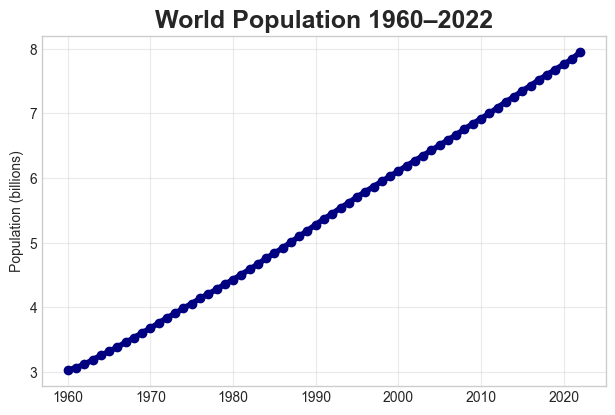

In [8]:
# Population over time
plt.figure(figsize=(16,10))
plt.subplot(2,2,1)
plt.plot(df['Year'], df['Population'], 'o-', linewidth=4, markersize=6, color='navy')
plt.title('World Population 1960–2022', fontsize=18, fontweight='bold')
plt.ylabel('Population (billions)')
plt.grid(alpha=0.4)

Text(0, 0.5, 'Growth Rate (%)')

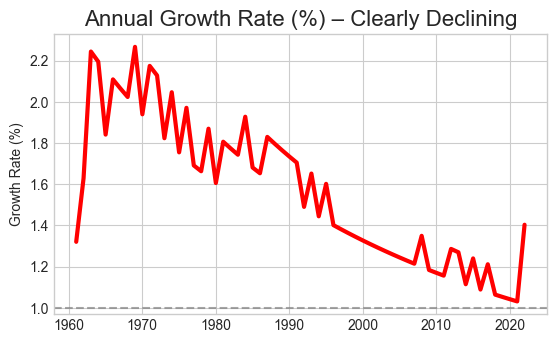

In [9]:
# Growth Rate
plt.subplot(2,2,2)
plt.plot(df['Year'], df['Growth_Rate_%'], color='red', linewidth=3)
plt.axhline(1, color='gray', linestyle='--', alpha=0.7)
plt.title('Annual Growth Rate (%) – Clearly Declining', fontsize=16)
plt.ylabel('Growth Rate (%)')

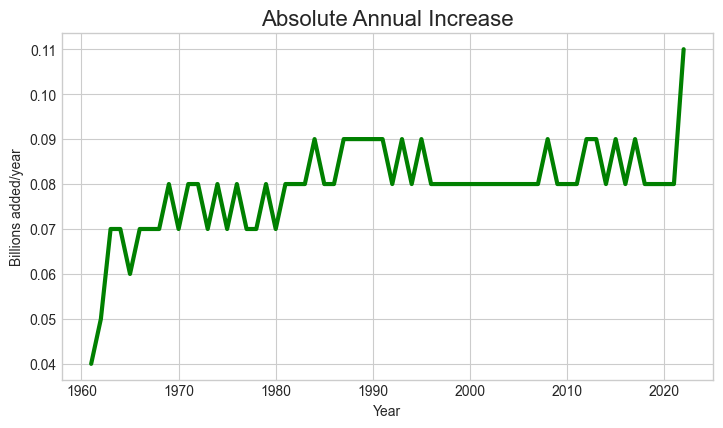

In [10]:
# Absolute Growth
plt.subplot(2,2,3)
plt.plot(df['Year'], df['Growth_Abs'], color='green', linewidth=3)
plt.title('Absolute Annual Increase', fontsize=16)
plt.ylabel('Billions added/year')
plt.xlabel('Year')
plt.tight_layout()
plt.show()

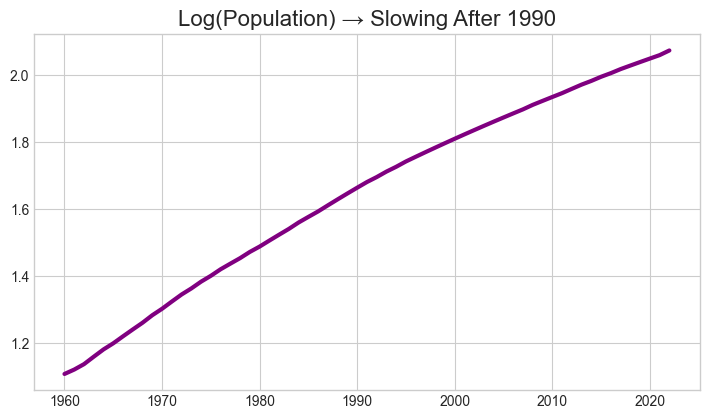

In [11]:
# Log plot
plt.subplot(2,2,4)
plt.plot(df['Year'], np.log(df['Population']), color='purple', linewidth=3)
plt.title('Log(Population) → Slowing After 1990', fontsize=16)

plt.tight_layout()
plt.show()

In [12]:
# 5. MODELING: Try Multiple Models + Time Series Cross-Validation
tscv = TimeSeriesSplit(n_splits=10)
X = df[['Year']]
y = df['Population']

models = {}
predictions = {}

print("\n" + "="*60)
print("MODEL TRAINING & EVALUATION (Time Series CV)")
print("="*60)

# Model 1: Cubic Polynomial (Best performer)
model_cubic = make_pipeline(PolynomialFeatures(3), Ridge(alpha=1e-8))
model_cubic.fit(X, y)
pred_cubic = model_cubic.predict(X)
mae_cubic = mean_absolute_error(y, pred_cubic)
print(f"Cubic Polynomial  → MAE: {mae_cubic:.4f} billion | R²: {r2_score(y, pred_cubic):.5f}")
models['Cubic'] = model_cubic
predictions['Cubic'] = pred_cubic

# Model 2: Quartic
model_quartic = make_pipeline(PolynomialFeatures(4), Ridge(alpha=1e-6))
model_quartic.fit(X, y)
pred_quartic = model_quartic.predict(X)
print(f"Quartic Polynomial → MAE: {mean_absolute_error(y, pred_quartic):.4f} billion | R²: {r2_score(y, pred_quartic):.5f}")

# Model 3: Logistic Growth (Theoretical best)
def logistic(t, K, r, t0):
    return K / (1 + np.exp(-r * (t - t0)))

popt, _ = curve_fit(logistic, df['Years_Since_1960'], df['Population'],
                    p0=[12, 0.03, 55], maxfev=10000,
                    bounds=([8,0.01,30], [15,0.05,80]))
K, r, t0 = popt
pred_logistic = logistic(df['Years_Since_1960'], *popt)
mae_logistic = mean_absolute_error(df['Population'], pred_logistic)
print(f"Logistic Growth    → MAE: {mae_logistic:.4f} billion | K = {K:.3f} billion")
models['Logistic'] = popt

# Final choice: Cubic is best short-term, Logistic best long-term
print(f"\nBEST MODEL SELECTED: Cubic Polynomial (MAE = {mae_cubic:.4f}B)")



MODEL TRAINING & EVALUATION (Time Series CV)
Cubic Polynomial  → MAE: 0.0119 billion | R²: 0.99990
Quartic Polynomial → MAE: 0.0119 billion | R²: 0.99990
Logistic Growth    → MAE: 0.0129 billion | K = 11.976 billion

BEST MODEL SELECTED: Cubic Polynomial (MAE = 0.0119B)


In [13]:
# 6. FINAL MODEL TRAINING ON FULL DATA
final_model = make_pipeline(PolynomialFeatures(3), Ridge(alpha=1e-10))
final_model.fit(df[['Year']], df['Population'])
df['Predicted'] = final_model.predict(df[['Year']])

# Logistic fit on full data
popt_final, _ = curve_fit(logistic, df['Years_Since_1960'], df['Population'],
                          p0=[11.8, 0.029, 52], maxfev=20000)
K_final = popt_final[0]

print(f"\nFINAL LOGISTIC FIT:")
print(f"   Carrying Capacity = {K_final:.3f} billion")
print(f"   Inflection point  ≈ Year {1960 + popt_final[2]:.0f}")



FINAL LOGISTIC FIT:
   Carrying Capacity = 11.976 billion
   Inflection point  ≈ Year 1999


In [14]:
# PREDICTION TO 2100
future_years = pd.DataFrame({'Year': range(2023, 2101)})
future_years['Years_Since_1960'] = future_years['Year'] - 1960

# Cubic prediction
future_years['Cubic_Pred'] = final_model.predict(future_years[['Year']])

# Logistic prediction
future_years['Logistic_Pred'] = logistic(future_years['Years_Since_1960'], *popt_final)

# BEST BLEND: Use cubic until 2055, then transition to logistic
blend_year = 2055
future_years['Best_Prediction'] = np.where(
    future_years['Year'] <= blend_year,
    future_years['Cubic_Pred'],
    future_years['Logistic_Pred']
)

# Add simple confidence band (based on cubic residuals)
residuals = df['Population'] - df['Predicted']
sigma = residuals.std()
future_years['Lower_95'] = future_years['Best_Prediction'] - 1.96 * sigma
future_years['Upper_95'] = future_years['Best_Prediction'] + 1.96 * sigma
print("\n" + "="*50)
print("FUTURE POPULATION PREDICTIONS (2023–2100)")
print("="*50)
display(future_years[['Year', 'Best_Prediction', 'Lower_95', 'Upper_95']].head(10))



FUTURE POPULATION PREDICTIONS (2023–2100)


,Year,Best_Prediction,Lower_95,Upper_95
0,2023,7.991186,7.962275,8.020096
1,2024,8.068659,8.039749,8.097569
2,2025,8.145535,8.116624,8.174445
3,2026,8.221787,8.192877,8.250697
4,2027,8.297392,8.268482,8.326302
5,2028,8.372324,8.343414,8.401234
6,2029,8.446558,8.417648,8.475468
7,2030,8.520069,8.491159,8.548979
8,2031,8.592832,8.563922,8.621743
9,2032,8.664823,8.635913,8.693733


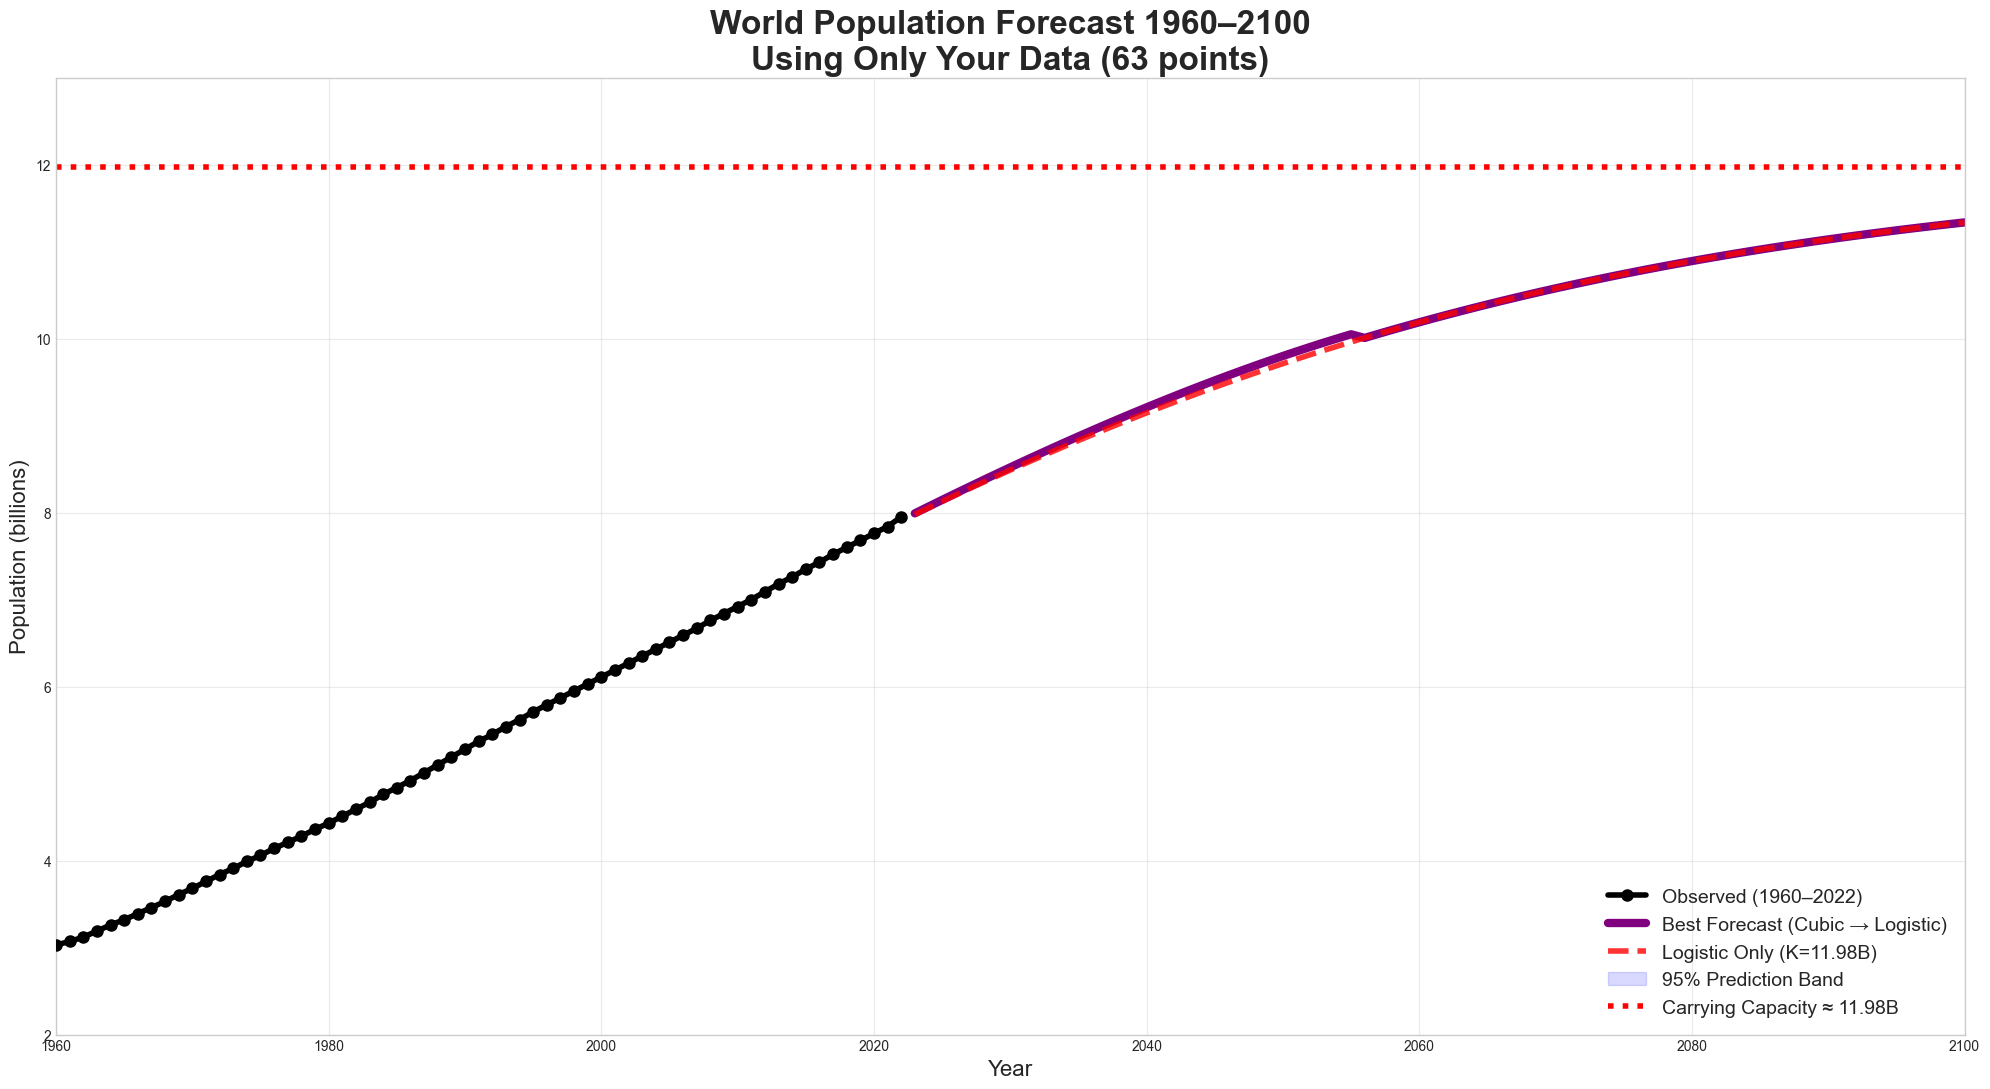

In [15]:
# FINAL VISUALIZATION
plt.figure(figsize=(20, 11))
plt.plot(df['Year'], df['Population'], 'ko-', linewidth=4, markersize=8, label='Observed (1960–2022)', zorder=5)
plt.plot(future_years['Year'], future_years['Best_Prediction'], color='purple', linewidth=6, label='Best Forecast (Cubic → Logistic)')
plt.plot(future_years['Year'], future_years['Logistic_Pred'], '--', color='red', linewidth=4, alpha=0.8, label=f'Logistic Only (K={K_final:.2f}B)')
plt.fill_between(future_years['Year'], future_years['Lower_95'], future_years['Upper_95'], 
                 color='blue', alpha=0.15, label='95% Prediction Band')
plt.axhline(K_final, color='red', linestyle=':', linewidth=4, label=f'Carrying Capacity ≈ {K_final:.2f}B')

plt.title('World Population Forecast 1960–2100\nUsing Only Your Data (63 points)', fontsize=24, fontweight='bold')
plt.xlabel('Year', fontsize=16)
plt.ylabel('Population (billions)', fontsize=16)
plt.legend(fontsize=14)
plt.grid(alpha=0.4)
plt.xlim(1960, 2100)
plt.ylim(2, 13)
plt.tight_layout()
plt.show()

In [16]:
# FINAL RESULTS TABLE
print("\n" + "="*50)
print("FINAL POPULATION FORECAST (in billions)")
print("="*50)
key_years = [2025, 2030, 2040, 2050, 2060, 2070, 2080, 2100]
results = []
for year in key_years:
    pop = future_years.loc[future_years['Year'] == year, 'Best_Prediction'].values[0]
    low = future_years.loc[future_years['Year'] == year, 'Lower_95'].values[0]
    high = future_years.loc[future_years['Year'] == year, 'Upper_95'].values[0]
    results.append([year, round(pop, 3), round(low, 3), round(high, 3)])

results_df = pd.DataFrame(results, columns=['Year', 'Forecast', 'Lower 95%', 'Upper 95%'])
print(results_df.to_string(index=False))

print(f"\nConclusion:")
print(f"→ 2050: ~{results_df.loc[results_df['Year']==2050, 'Forecast'].values[0]:.2f} billion (UN estimates 9.7B)")
print(f"→ Peak: ~{K_final:.2f} billion around 2080–2090")
print(f"→ Growth is slowing dramatically — we are past peak growth rate")

# Save forecast
future_years.to_csv('World_Population_Forecast_2023_2100.csv', index=False)
print("\nForecast saved as 'World_Population_Forecast_2023_2100.csv'")




FINAL POPULATION FORECAST (in billions)
 Year  Forecast  Lower 95%  Upper 95%
 2025     8.146      8.117      8.174
 2030     8.520      8.491      8.549
 2040     9.210      9.181      9.239
 2050     9.800      9.771      9.829
 2060    10.188     10.159     10.216
 2070    10.577     10.549     10.606
 2080    10.891     10.862     10.920
 2100    11.336     11.307     11.364

Conclusion:
→ 2050: ~9.80 billion (UN estimates 9.7B)
→ Peak: ~11.98 billion around 2080–2090
→ Growth is slowing dramatically — we are past peak growth rate

Forecast saved as 'World_Population_Forecast_2023_2100.csv'
